In [9]:
# This code is inspired and with the help of: https://github.com/TheodoreWolf/pinns
import functools
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as thdat
import seaborn as sns

In [16]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
def grad(outputs, inputs):
    """Computes the partial derivative of 
    an output with respect to an input.
    Args:
        outputs: (N, 1) tensor containing the output values 
                 for which we want to compute the gradients.
        inputs: (N, D) tensor containing the input values 
                with respect to which the gradients are calculated.
    Returns:
        A tuple containing the gradients of the outputs 
        with respect to the inputs. The shape of the gradients 
        will be (N, D), where D is the number of dimensions in the input.

    Note:
        This function utilizes PyTorch's autograd functionality to 
        automatically compute the gradients. The parameter 
        `grad_outputs` is set to a tensor of ones with the same shape 
        as `outputs`, indicating that we want the gradients of the 
        outputs with respect to the inputs. By setting 
        `create_graph=True`, we allow the computation of higher-order 
        derivatives, which can be useful for certain applications.
    """
    return torch.autograd.grad(outputs, inputs, grad_outputs=torch.ones_like(outputs), create_graph=True)


def cooling_law(time, Tenv, T0, R):
    """Calculates the temperature of an object over time 
    as it cools or warms towards the environmental temperature 
    based on Newton's Law of Cooling.

    Args:
        time: A scalar or array representing time (e.g., in seconds).
        Tenv: The ambient or environmental temperature (in degrees).
        T0: The initial temperature of the object (in degrees).
        R: The cooling constant, which influences the rate of temperature change.

    Returns:
        A scalar or array representing the temperature of the object 
        at the given time, calculated using the cooling law formula.
    
    Note:
        The formula used is:
        T(t) = Tenv + (T0 - Tenv) * exp(-R * t)
        where:
        - T(t) is the temperature at time t,
        - Tenv is the environmental temperature,
        - T0 is the initial temperature,
        - R is the cooling constant,
        - exp is the exponential function.
    """
    T = Tenv + (T0 - Tenv) * np.exp(-R * time)
    return T


def np_to_th(x):
    """Converts a NumPy array to a PyTorch tensor, 
    moves it to the specified device, and reshapes it.

    Args:
        x: A NumPy array that is to be converted to a PyTorch tensor.

    Returns:
        A PyTorch tensor of shape (n_samples, -1), 
        where n_samples is the number of samples in the input array.
    
    Note:
        - The input NumPy array `x` is first converted to a PyTorch tensor.
        - The tensor is then cast to a floating-point type.
        - The tensor is moved to a predefined device (e.g., CPU or GPU) specified by `DEVICE`.
        - Finally, the tensor is reshaped to ensure that it has two dimensions, 
          with the first dimension representing the number of samples and 
          the second dimension inferred automatically.
    """
    n_samples = len(x)
    return torch.from_numpy(x).to(torch.float).to(DEVICE).reshape(n_samples, -1)

In [18]:
# Parameters:
    # input_dim: Number of input features.
    # output_dim: Number of output features.
    # n_units: Number of hidden units in each layer (default is 100).
    # epochs: Number of training epochs (default is 1000).
    # loss: Loss function (default is Mean Squared Error).
    # lr: Learning rate for the optimizer.
    # loss2: An optional secondary loss function.
    # loss2_weight: Weight for the secondary loss.

class Net(nn.Module):
    def __init__(
        self,
        input_dim, 
        output_dim,
        n_units=100,
        epochs=1000,
        loss=nn.MSELoss(),
        lr=1e-3,
        loss2=None,
        loss2_weight=0.1,
    ) -> None:
        super().__init__()

        self.epochs = epochs
        self.loss = loss
        self.loss2 = loss2
        self.loss2_weight = loss2_weight
        self.lr = lr
        self.n_units = n_units
        # Layer Definition
        self.layers = nn.Sequential(
            nn.Linear(input_dim, self.n_units),
            nn.ReLU(),
            nn.Linear(self.n_units, self.n_units),
            nn.ReLU(),
            nn.Linear(self.n_units, self.n_units),
            nn.ReLU(),
            nn.Linear(self.n_units, self.n_units),
            nn.ReLU(),
        )
        self.out = nn.Linear(self.n_units, output_dim)

    # This method defines how the input data flows through the network. It applies the layers sequentially to input x and returns the output
    def forward(self, x):
        h = self.layers(x)
        out = self.out(h)
        return out

    def fit(self, X, y):
        # Converts NumPy arrays X and y to PyTorch tensors 
        Xt = np_to_th(X)
        yt = np_to_th(y)

        optimiser = optim.Adam(self.parameters(), lr=self.lr)
        self.train()
        losses = []
        for ep in range(self.epochs):
            optimiser.zero_grad()
            outputs = self.forward(Xt)
            loss = self.loss(yt, outputs)
            if self.loss2:
                loss += self.loss2_weight * self.loss2(self)
            loss.backward()
            optimiser.step()
            losses.append(loss.item())
            if ep % int(self.epochs / 10) == 0:
                print(f"Epoch {ep}/{self.epochs}, loss: {losses[-1]:.2f}")
        return losses

    def predict(self, X):
        self.eval()
        out = self.forward(np_to_th(X))
        return out.detach().cpu().numpy()


class NetDiscovery(Net):
    def __init__(
        self,
        input_dim,
        output_dim,
        n_units=100,
        epochs=1000,
        loss=nn.MSELoss(),
        lr=0.001,
        loss2=None,
        loss2_weight=0.1,
    ) -> None:
        super().__init__(
            input_dim, output_dim, n_units, epochs, loss, lr, loss2, loss2_weight
        )

        self.r = nn.Parameter(data=torch.tensor([0.]))


In [20]:
sns.set_theme()
torch.manual_seed(42)

np.random.seed(10)

Tenv = 25 # The ambient temperature (in °C)
T0 = 100 # The initial temperature of the object (in °C)
R = 0.005 # A constant representing the cooling rate

# Creates an array of 1000 evenly spaced values between 0 and 1000 seconds. This will be used to calculate the temperatures over time.
times = np.linspace(0, 1000, 1000)
eq = functools.partial(cooling_law, Tenv=Tenv, T0=T0, R=R)
temps = eq(times)
print(temps[:10])  # Print the first 10 temperature values

[100.          99.62556244  99.25299425  98.88228612  98.51342874
  98.14641289  97.78122936  97.41786901  97.05632274  96.69658149]


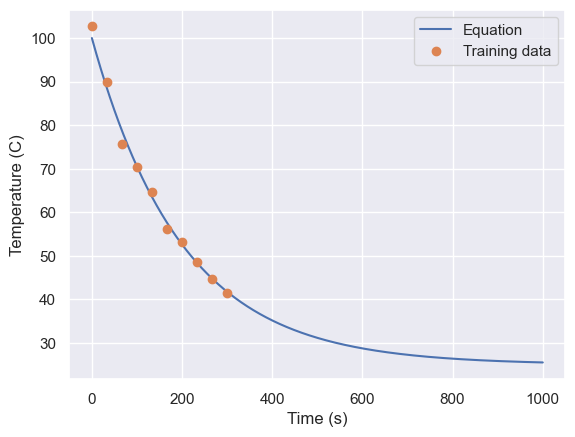

In [22]:
# Make training data
# Creates an array of 10 evenly spaced values between 0 and 300 seconds for the training data
t = np.linspace(0, 300, 10) 
# Calculates the temperatures at these time points using the cooling law, and adds some random noise (with a standard deviation of 2) to simulate observed data. This mimics real-world measurement uncertainty
T = eq(t) +  2 * np.random.randn(10)

plt.plot(times, temps)
plt.plot(t, T, 'o')
plt.legend(['Equation', 'Training data'])
plt.ylabel('Temperature (C)')
plt.xlabel('Time (s)')
plt.show()

Epoch 0/20000, loss: 4713.87
Epoch 2000/20000, loss: 2510.65
Epoch 4000/20000, loss: 2154.42
Epoch 6000/20000, loss: 763.29
Epoch 8000/20000, loss: 97.57
Epoch 10000/20000, loss: 2.34
Epoch 12000/20000, loss: 0.48
Epoch 14000/20000, loss: 0.40
Epoch 16000/20000, loss: 0.33
Epoch 18000/20000, loss: 0.33


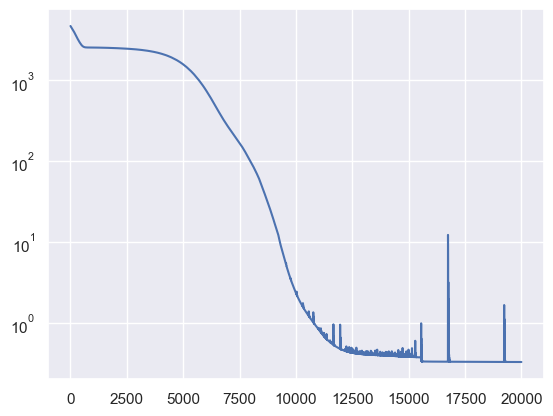

In [24]:
net = Net(1,1, loss2=None, epochs=20000, lr=1e-5).to(DEVICE)
losses = net.fit(t, T)

plt.plot(losses)
plt.yscale('log')
plt.show()

In [26]:
def l2_reg(model: torch.nn.Module):
    """Calculates the L2 regularization term for a given model.

    Args:
        model: An instance of a PyTorch neural network model 
               (subclass of torch.nn.Module).

    Returns:
        A tensor representing the L2 regularization term, 
        which is the sum of the squares of all model parameters.
    
    Note:
        - L2 regularization helps prevent overfitting by adding a penalty 
          proportional to the square of the magnitude of parameters to the loss function.
        - The function iterates over all parameters of the model, 
          computes the square of each parameter, and sums them all.
    """
    return torch.sum(sum([p.pow(2.) for p in model.parameters()]))

Epoch 0/20000, loss: 11219.99
Epoch 2000/20000, loss: 3923.51
Epoch 4000/20000, loss: 2436.71
Epoch 6000/20000, loss: 1606.24
Epoch 8000/20000, loss: 1202.36
Epoch 10000/20000, loss: 1018.77
Epoch 12000/20000, loss: 925.61
Epoch 14000/20000, loss: 861.94
Epoch 16000/20000, loss: 797.07
Epoch 18000/20000, loss: 734.07


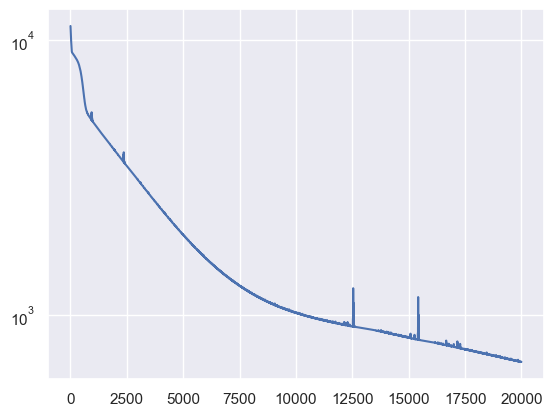

In [28]:
netreg = Net(1,1, loss2=l2_reg, epochs=20000, lr=1e-4, loss2_weight=1).to(DEVICE)

losses = netreg.fit(t, T)

plt.plot(losses)
plt.yscale('log')
plt.show()

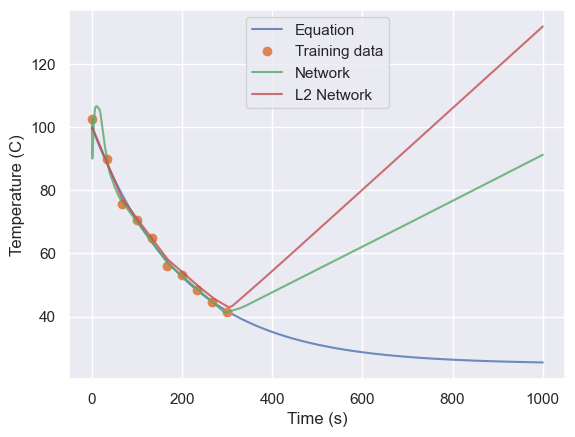

In [30]:
predsreg = netreg.predict(times)
preds = net.predict(times)
plt.plot(times, temps, alpha=0.8)
plt.plot(t, T, 'o')
plt.plot(times, preds, alpha=0.8)
plt.plot(times, predsreg, alpha=0.8)

plt.legend(labels=['Equation','Training data', 'Network', 'L2 Network'])
plt.ylabel('Temperature (C)')
plt.xlabel('Time (s)')
plt.show()

In [32]:
def physics_loss(model: torch.nn.Module):
    """Calculates the physics-based loss for a given model 
    by evaluating the discrepancy from a defined physical law.

    Args:
        model: An instance of a PyTorch neural network model 
               (subclass of torch.nn.Module) that predicts temperatures.

    Returns:
        A scalar tensor representing the mean squared error 
        of the physical law applied to the model's predictions.
    
    Note:
        - The function generates a tensor `ts` representing time values 
          from 0 to 1000 seconds, divided into 1000 evenly spaced steps.
        - The time tensor is reshaped and set to require gradients for 
          automatic differentiation.
        - The model is used to predict temperatures (`temps`) based on the time tensor.
        - The gradient of the predicted temperatures with respect to time is computed 
          using the `grad` function, which represents the rate of change of temperature.
        - The loss is computed based on the physical law, where `pde` represents 
          the difference between the expected and actual behavior (in this case, 
          modeled by the term R*(Tenv - temps) - dT).
        - Finally, the function returns the mean squared error of the `pde`, 
          encouraging the model to adhere to the physical principles defined.
    """
    ts = torch.linspace(0, 1000, steps=1000,).view(-1,1).requires_grad_(True).to(DEVICE)
    temps = model(ts)
    dT = grad(temps, ts)[0]
    pde = R*(Tenv - temps) - dT    
    return torch.mean(pde**2)

Epoch 0/30000, loss: 4775.84
Epoch 3000/30000, loss: 2435.22
Epoch 6000/30000, loss: 543.17
Epoch 9000/30000, loss: 1.02
Epoch 12000/30000, loss: 0.39
Epoch 15000/30000, loss: 0.38
Epoch 18000/30000, loss: 0.35
Epoch 21000/30000, loss: 0.34
Epoch 24000/30000, loss: 0.33
Epoch 27000/30000, loss: 0.34


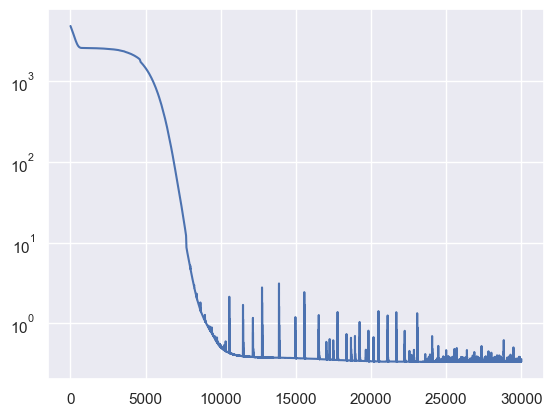

In [34]:
net = Net(1,1, loss2=physics_loss, epochs=30000, loss2_weight=1, lr=1e-5).to(DEVICE)

losses = net.fit(t, T)
plt.plot(losses)
plt.yscale('log')
plt.show()

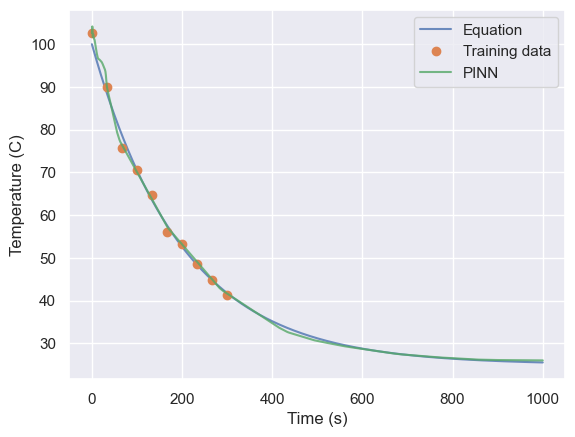

In [36]:
preds = net.predict(times)

plt.plot(times, temps, alpha=0.8)
plt.plot(t, T, 'o')
plt.plot(times, preds, alpha=0.8)
plt.legend(labels=['Equation','Training data', 'PINN'])
plt.ylabel('Temperature (C)')
plt.xlabel('Time (s)')
plt.show()

In [38]:
def physics_loss_discovery(model: torch.nn.Module):
    """Calculates a physics-based loss for a given model, 
    specifically designed for discovery or exploration of physical laws.

    Args:
        model: An instance of a PyTorch neural network model 
               (subclass of torch.nn.Module) that predicts temperatures 
               and contains a parameter `r`.

    Returns:
        A scalar tensor representing the mean squared error 
        of the physical law applied to the model's predictions.
    
    Note:
        - The function generates a tensor `ts` representing time values 
          from 0 to 1000 seconds, divided into 1000 evenly spaced steps.
        - The time tensor is reshaped and set to require gradients for 
          automatic differentiation.
        - The model is used to predict temperatures (`temps`) based on the time tensor.
        - The gradient of the predicted temperatures with respect to time is computed 
          using the `grad` function, which represents the rate of change of temperature.
        - The loss is computed based on the physical law, where `pde` represents 
          the difference between the expected behavior defined by the model's parameter 
          `r` and the actual rate of temperature change.
        - Finally, the function returns the mean squared error of the `pde`, 
          encouraging the model to adhere to the physical principles defined.
    """
    ts = torch.linspace(0, 1000, steps=1000,).view(-1,1).requires_grad_(True).to(DEVICE)
    temps = model(ts)
    dT = grad(temps, ts)[0]
    pde = model.r * (Tenv - temps) - dT
    
    return torch.mean(pde**2)

Epoch 0/40000, loss: 4816.01
Epoch 4000/40000, loss: 2499.90
Epoch 8000/40000, loss: 2050.93
Epoch 12000/40000, loss: 493.98
Epoch 16000/40000, loss: 3.65
Epoch 20000/40000, loss: 1.70
Epoch 24000/40000, loss: 1.13
Epoch 28000/40000, loss: 0.58
Epoch 32000/40000, loss: 0.35
Epoch 36000/40000, loss: 0.24


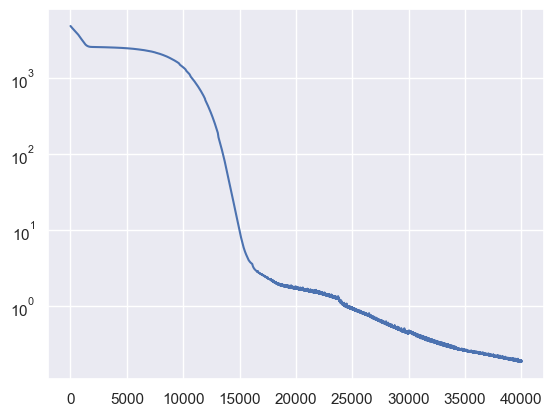

In [40]:
netdisc = NetDiscovery(1, 1, loss2=physics_loss_discovery, loss2_weight=1, epochs=40000, lr= 5e-6).to(DEVICE)

losses = netdisc.fit(t, T)
plt.plot(losses)
plt.yscale('log')
plt.show()

Parameter containing:
tensor([0.0050], requires_grad=True)


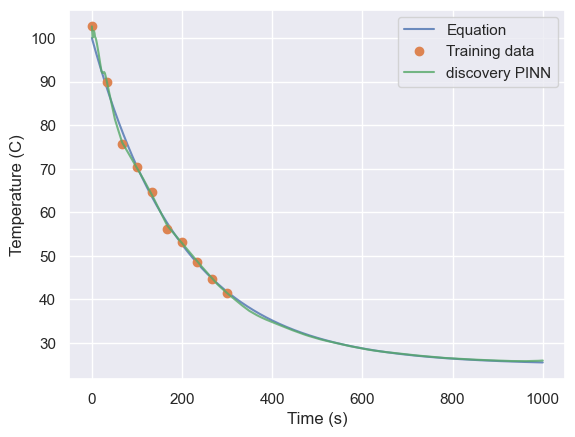

In [42]:
preds = netdisc.predict(times)
print(netdisc.r)

plt.plot(times, temps, alpha=0.8)
plt.plot(t, T, 'o')
plt.plot(times, preds, alpha=0.8)
plt.legend(labels=['Equation','Training data', 'discovery PINN'])
plt.ylabel('Temperature (C)')
plt.xlabel('Time (s)')
plt.show()